### Этап 1. Загрузка и подготовка данных
Скачайте или используйте предоставленный набор данных botsv1,
содержащий логи WinEventLog и DNS.
Загрузите данные в датафреймы с помощью Pandas.
При необходимости выполните нормализацию данных: приведение
к единому формату, очистку.
### Этап 2. Анализ данных
Проанализируйте два типа логов: \
для WinEventLog найдите подозрительные события по полю EventID,
например, входы с ошибками, эскалация привилегий и прочие; \
 для DNS-логов определите потенциально вредоносные
или подозрительные запросы, например, частые обращения
к редким доменам, нестандартные поддомены. 
### Этап 3. Визуализация данных
Составьте график топ-10 подозрительных событий.
Можно построить отдельные диаграммы для WinEventLog и DNS-логов
или объединённую визуализацию.
Используйте Seaborn или Matplotlib для создания графиков.

In [3]:
import json
import re
import math
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_colwidth", 120)


In [4]:
DATA_PATH = Path("botsv1.json")

def _coerce_scalar(x):
    if isinstance(x, list):
        return x[-1] if len(x) else None
    return x

def load_botsv1(path: Path) -> pd.DataFrame:
    text = path.read_text(encoding="utf-8", errors="ignore").strip()

    rows = []
    if text.startswith("["):
        obj = json.loads(text)
        for item in obj:
            if isinstance(item, dict) and "result" in item and isinstance(item["result"], dict):
                rows.append(item["result"])
            else:
                rows.append(item)
    else:
        for line in text.splitlines():
            line = line.strip()
            if not line:
                continue
            item = json.loads(line)
            if isinstance(item, dict) and "result" in item and isinstance(item["result"], dict):
                rows.append(item["result"])
            else:
                rows.append(item)

    df = pd.DataFrame(rows)

    for col in df.columns:
        df[col] = df[col].map(_coerce_scalar)

    if "_time" in df.columns:

        def parse_time(s):
            if pd.isna(s):
                return pd.NaT
            s = str(s)
            m = re.search(r"\d{4}-\d{2}-\d{2}\s+\d{2}:\d{2}:\d{2}(?:\.\d+)?", s)
            return pd.to_datetime(m.group(0)) if m else pd.to_datetime(s, errors="coerce")

        df["_time_parsed"] = df["_time"].map(parse_time)

    return df

df = load_botsv1(DATA_PATH)
print("Всего событий:", len(df))
df.head(3)


Всего событий: 35


C:\Users\Dmitriy\AppData\Local\Temp\ipykernel_19556\563973005.py:44: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df["_time_parsed"] = df["_time"].map(parse_time)


,Account_Domain,Account_Name,ComputerName,Creator_Process_ID,EventCode,EventType,Keywords,LogName,Logon_ID,Message,...,Object_Server,Object_Type,Privileges_Used_for_Access_Check,ReadData__or_ListDirectory_,Resource_Attributes,Restricted_SID_Count,Transaction_ID,privilege_id,vendor_privilege,_time_parsed
0,WAYNECORPINC,we3436srv$,we3436srv.waynecorpinc.local,0xddc,4688,0,Audit Success,Security,0x3E7,A new process has been created.\n\nSubject:\n\tSecurity ID:\t\tNT AUTHORITY\SYSTEM\n\tAccount Name:\t\twe3436srv$\n\...,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2016-08-28 16:02:21
1,WAYNECORPINC,we1159srv$,we1159srv.waynecorpinc.local,NaN,4689,0,Audit Success,Security,0x3E7,A process has exited.\n\nSubject:\n\tSecurity ID:\t\tNT AUTHORITY\SYSTEM\n\tAccount Name:\t\twe1159srv$\n\tAccount D...,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2016-08-28 16:02:21
2,WAYNECORPINC,we9028srv$,we9028srv.waynecorpinc.local,NaN,4624,0,Audit Success,Security,0x15D68DA,An account was successfully logged on.\n\nSubject:\n\tSecurity ID:\t\tNULL SID\n\tAccount Name:\t\t-\n\tAccount Doma...,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2016-08-28 16:02:20


In [5]:
# === Разделение на WinEventLog и DNS ===

def is_wineventlog(row: pd.Series) -> bool:
    for key in ("sourcetype", "source", "object"):
        v = row.get(key)
        if isinstance(v, str) and "wineventlog" in v.lower():
            return True
    return False

def is_dns(row: pd.Series) -> bool:
    for key in ("sourcetype", "source", "object"):
        v = row.get(key)
        if isinstance(v, str) and "dns" in v.lower() and "wineventlog" not in v.lower():
            return True
    ev = row.get("eventtype")
    if isinstance(ev, (list, tuple)):
        return any(isinstance(x, str) and "dns" in x.lower() for x in ev)
    return False

win_df = df[df.apply(is_wineventlog, axis=1)].copy()
dns_df = df[df.apply(is_dns, axis=1)].copy()

print("WinEventLog:", len(win_df))
print("DNS:", len(dns_df))

win_df.head(2)


WinEventLog: 35
DNS: 0


,Account_Domain,Account_Name,ComputerName,Creator_Process_ID,EventCode,EventType,Keywords,LogName,Logon_ID,Message,...,Object_Server,Object_Type,Privileges_Used_for_Access_Check,ReadData__or_ListDirectory_,Resource_Attributes,Restricted_SID_Count,Transaction_ID,privilege_id,vendor_privilege,_time_parsed
0,WAYNECORPINC,we3436srv$,we3436srv.waynecorpinc.local,0xddc,4688,0,Audit Success,Security,0x3E7,A new process has been created.\n\nSubject:\n\tSecurity ID:\t\tNT AUTHORITY\SYSTEM\n\tAccount Name:\t\twe3436srv$\n\...,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2016-08-28 16:02:21
1,WAYNECORPINC,we1159srv$,we1159srv.waynecorpinc.local,NaN,4689,0,Audit Success,Security,0x3E7,A process has exited.\n\nSubject:\n\tSecurity ID:\t\tNT AUTHORITY\SYSTEM\n\tAccount Name:\t\twe1159srv$\n\tAccount D...,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2016-08-28 16:02:21


## Этап 2 (часть 1). WinEventLog: поиск подозрительных событий по EventID
Мы помечаем событие как подозрительное, если его `EventCode` попадает в список:

- `4625` — неуспешный вход (failed logon)  
- `4672` — special privileges assigned  
- `4703` — user right adjusted (изменение прав/привилегий)  
- `4719` — audit policy changed  
- `4720/4726` — создание/удаление пользователя  
- `4728/4732/4756` — добавление в группы (особенно админские)  
- `4688` — создание процесса (дополнительно отметим подозрительные командные строки)  
- `1102` — очистка журнала Security



In [6]:
# EventID
SUSPICIOUS_EVENTCODES = {
    "4625",  # failed logon
    "4672",  # special privileges
    "4703",  # user right adjusted
    "4719",  # audit policy changed
    "4720",  # user created
    "4726",  # user deleted
    "4728", "4732", "4756",  # added to group
    "4688",  # process creation
    "4697",  # service installed (если есть)
    "1102",  # audit log cleared
}

def get_eventcode(row: pd.Series):
    for c in ("EventCode", "signature_id", "EventID", "event_id"):
        v = row.get(c)
        if pd.isna(v):
            continue
        v = str(v).strip()
        if v:
            return v
    return None

if len(win_df):
    win_df["EventCode_norm"] = win_df.apply(get_eventcode, axis=1)

#lolbins
SUSPICIOUS_CMD_SUBSTR = [
    "powershell", "pwsh", "cmd.exe", "wscript", "cscript", "mshta", "rundll32",
    "reg.exe", "schtasks", "wmic", "bitsadmin", "certutil", "whoami", "net user", "net localgroup"
]

def suspicious_process_creation(row: pd.Series) -> bool:
    if row.get("EventCode_norm") != "4688":
        return False
    cmd = row.get("Process_Command_Line") or row.get("CommandLine") or row.get("Message") or ""
    cmd = str(cmd).lower()
    return any(s in cmd for s in SUSPICIOUS_CMD_SUBSTR)

if len(win_df):
    win_df["is_suspicious_by_id"] = win_df["EventCode_norm"].isin(SUSPICIOUS_EVENTCODES)
    win_df["is_suspicious_4688_cmd"] = win_df.apply(suspicious_process_creation, axis=1)
    win_df["is_suspicious"] = win_df["is_suspicious_by_id"] | win_df["is_suspicious_4688_cmd"]

    suspicious_win = win_df[win_df["is_suspicious"]].copy()
    print("Подозрительных WinEventLog событий:", len(suspicious_win))
else:
    suspicious_win = win_df.copy()
    print("В данных нет WinEventLog записей.")

cols = [c for c in ["EventCode_norm", "name", "TaskCategory", "ComputerName", "_time_parsed"] if c in suspicious_win.columns]
suspicious_win[cols].head(10)


Подозрительных WinEventLog событий: 21


,EventCode_norm,name,TaskCategory,ComputerName,_time_parsed
0,4688,A new process has been created,Process Creation,we3436srv.waynecorpinc.local,2016-08-28 16:02:21
3,4703,NaN,Authorization Policy Change,we5878srv.waynecorpinc.local,2016-08-28 16:02:20
4,4703,NaN,Authorization Policy Change,we3997srv.waynecorpinc.local,2016-08-28 16:02:20
5,4703,NaN,Authorization Policy Change,we9269srv.waynecorpinc.local,2016-08-28 16:02:20
7,4688,A new process has been created,Process Creation,we5689srv.waynecorpinc.local,2016-08-28 16:02:20
8,4703,NaN,Authorization Policy Change,we1662srv.waynecorpinc.local,2016-08-28 16:02:20
9,4688,A new process has been created,Process Creation,we3652srv.waynecorpinc.local,2016-08-28 16:02:20
11,4688,A new process has been created,Process Creation,we7006srv.waynecorpinc.local,2016-08-28 16:02:19
12,4688,A new process has been created,Process Creation,we8229srv.waynecorpinc.local,2016-08-28 16:02:19
13,4688,A new process has been created,Process Creation,we8592srv.waynecorpinc.local,2016-08-28 16:02:19


In [7]:
if len(suspicious_win):
    suspicious_win["event_label"] = suspicious_win.apply(
        lambda r: f'{r.get("EventCode_norm")} — {r.get("name") or r.get("signature") or r.get("TaskCategory") or "Unknown"}',
        axis=1
    )

    top10_win = suspicious_win["event_label"].value_counts().head(10).sort_values(ascending=True)
    display(top10_win.to_frame("count"))
else:
    top10_win = pd.Series(dtype=int)
    print("Нет подозрительных WinEventLog событий для топа.")


,count
event_label,
4688 — A new process has been created,9
4703 — nan,12


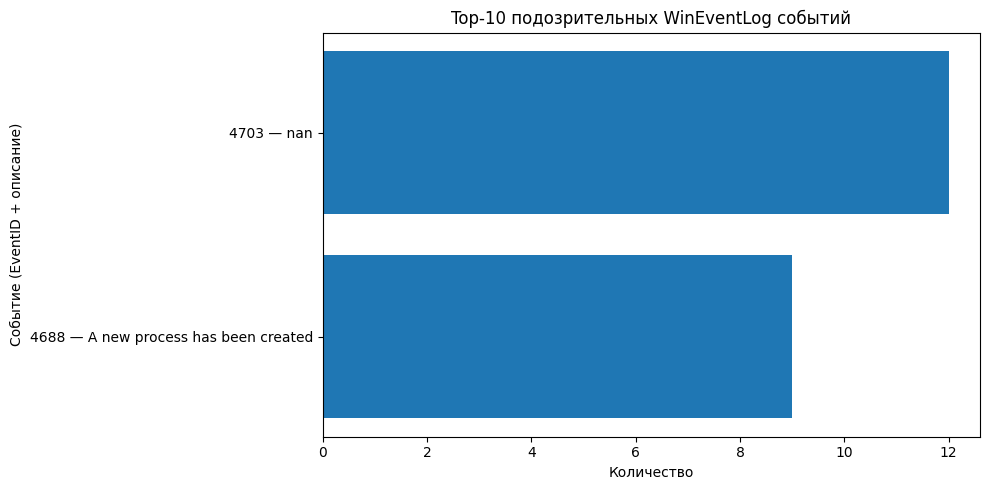

In [8]:
if len(top10_win):
    plt.figure(figsize=(10, 5))
    plt.barh(top10_win.index, top10_win.values)
    plt.title("Top-10 подозрительных WinEventLog событий")
    plt.xlabel("Количество")
    plt.ylabel("Событие (EventID + описание)")
    plt.tight_layout()
    plt.show()


## Этап 2 (часть 2). DNS: поиск подозрительных запросов

Используем несколько эвристик (можно применять все сразу):

1) **Длинные/нестандартные домены**  
   - длина FQDN > 60 или отдельная метка (label) > 30

2) **Высокая энтропия** (похоже на DGA/туннелирование)  
   - оцениваем энтропию левой метки (перед первым `.`)

3) **“Редкий домен, но частые обращения”**  
   - домен в целом встречается редко, но какой-то хост делает к нему много запросов

4) **Много уникальных поддоменов** для одного базового домена  
   - признак генерации поддоменов/туннелирования




In [9]:
# === DNS анализ ===

def extract_query_name(row: pd.Series):
    candidates = [
        "query", "Query", "query_name", "QueryName", "question", "rrname", "qname",
        "dest_host", "dest", "domain", "host", "name"
    ]
    for c in candidates:
        v = row.get(c)
        if pd.isna(v):
            continue
        v = str(v).strip()
        # грубая фильтрация: DNS имя обычно содержит точку и буквы
        if "." in v and len(v) >= 4 and not v.lower().startswith("win:"):
            return v.lower().strip(".")
    return None

# Энтропия Шеннона
def shannon_entropy(s: str) -> float:
    if not s:
        return 0.0
    s = s.lower()
    probs = [s.count(ch) / len(s) for ch in set(s)]
    return -sum(p * math.log2(p) for p in probs)

def registered_domain_simple(fqdn: str) -> str:
    parts = fqdn.strip(".").split(".")
    if len(parts) >= 2:
        return ".".join(parts[-2:])
    return fqdn

if len(dns_df) == 0:
    print("DNS-событий в текущем файле не найдено.")
    suspicious_dns = dns_df.copy()
else:
    dns_df["query_name"] = dns_df.apply(extract_query_name, axis=1)
    dns_df = dns_df[~dns_df["query_name"].isna()].copy()

    # базовый домен
    dns_df["reg_domain"] = dns_df["query_name"].map(registered_domain_simple)

    # не стандартный
    dns_df["fqdn_len"] = dns_df["query_name"].str.len()
    dns_df["max_label_len"] = dns_df["query_name"].map(lambda x: max((len(p) for p in x.split(".")), default=0))

    dns_df["left_label"] = dns_df["query_name"].map(lambda x: x.split(".")[0] if isinstance(x, str) and "." in x else x)
    dns_df["left_label_entropy"] = dns_df["left_label"].map(lambda x: shannon_entropy(str(x)))

    long_or_weird = (dns_df["fqdn_len"] > 60) | (dns_df["max_label_len"] > 30)
    high_entropy = dns_df["left_label_entropy"] >= 3.5

    global_domain_cnt = dns_df["reg_domain"].value_counts()
    dns_df["reg_domain_cnt"] = dns_df["reg_domain"].map(global_domain_cnt)

    host_col = None
    for c in ("src", "src_ip", "host", "ComputerName", "dvc"):
        if c in dns_df.columns:
            host_col = c
            break

    if host_col:
        host_dom_cnt = dns_df.groupby([host_col, "reg_domain"]).size().rename("host_dom_cnt").reset_index()
        dns_df = dns_df.merge(host_dom_cnt, on=[host_col, "reg_domain"], how="left")
        burst_thr = dns_df["host_dom_cnt"].quantile(0.95)
        rare_thr = dns_df["reg_domain_cnt"].quantile(0.50)
        rare_burst = (dns_df["host_dom_cnt"] >= burst_thr) & (dns_df["reg_domain_cnt"] <= rare_thr)
    else:
        rare_burst = pd.Series(False, index=dns_df.index)

    # много уникальных поддоменов на один reg_domain
    uniq_sub = dns_df.groupby("reg_domain")["query_name"].nunique()
    dns_df["uniq_subdomains"] = dns_df["reg_domain"].map(uniq_sub)
    many_subdomains = dns_df["uniq_subdomains"] >= max(10, int(uniq_sub.quantile(0.95)))

    # итоговая метка подозрительности
    dns_df["reason"] = np.select(
        [long_or_weird, high_entropy, rare_burst, many_subdomains],
        ["long_or_weird", "high_entropy", "rare_domain_burst", "many_unique_subdomains"],
        default="normal"
    )

    suspicious_dns = dns_df[dns_df["reason"] != "normal"].copy()
    print("Подозрительных DNS событий:", len(suspicious_dns))

    show_cols = [c for c in [host_col, "query_name", "reg_domain", "reason", "_time_parsed"] if c and c in suspicious_dns.columns]
    suspicious_dns[show_cols].head(10)


DNS-событий в текущем файле не найдено.


In [10]:
if len(suspicious_dns):
    top10_dns_domains = suspicious_dns["reg_domain"].value_counts().head(10).sort_values(ascending=True)
    display(top10_dns_domains.to_frame("count"))
else:
    top10_dns_domains = pd.Series(dtype=int)
    print("Нет подозрительных DNS событий для топа.")


Нет подозрительных DNS событий для топа.


In [11]:
if len(top10_dns_domains):
    plt.figure(figsize=(10, 5))
    plt.barh(top10_dns_domains.index, top10_dns_domains.values)
    plt.title("Top-10 подозрительных DNS доменов (registered domain)")
    plt.xlabel("Количество")
    plt.ylabel("Домен")
    plt.tight_layout()
    plt.show()


## Объединённая визуализация


,event,count,source
0,4688 — A new process has been created,9,WinEventLog
1,4703 — nan,12,WinEventLog


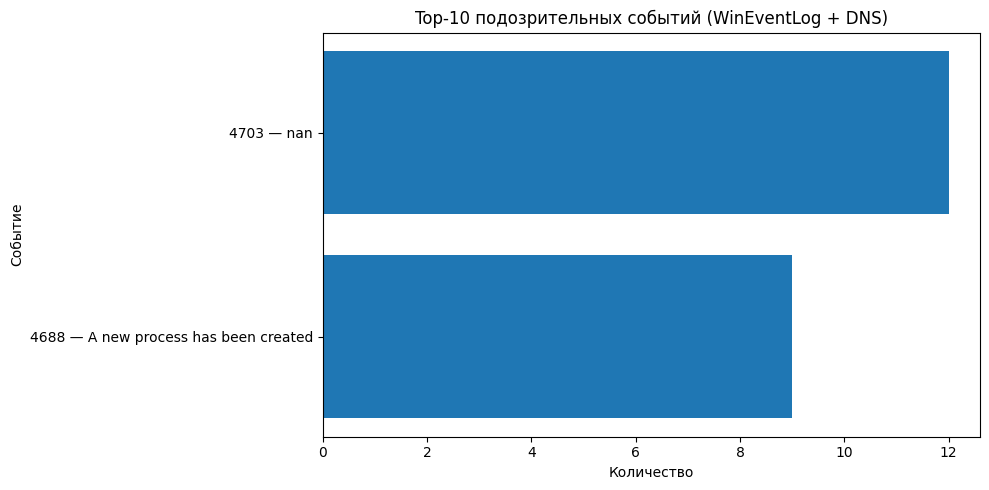

In [12]:
# === Объединённый топ-10 (WinEventLog + DNS) ===
combined = []

if len(top10_win):
    combined.append(pd.DataFrame({"event": top10_win.index, "count": top10_win.values, "source": "WinEventLog"}))

if len(top10_dns_domains):
    combined.append(pd.DataFrame({"event": top10_dns_domains.index, "count": top10_dns_domains.values, "source": "DNS"}))

if combined:
    combined_df = pd.concat(combined, ignore_index=True)
    combined_top10 = combined_df.sort_values("count", ascending=False).head(10).sort_values("count", ascending=True)
    display(combined_top10)

    plt.figure(figsize=(10, 5))
    plt.barh(combined_top10["event"], combined_top10["count"])
    plt.title("Top-10 подозрительных событий (WinEventLog + DNS)")
    plt.xlabel("Количество")
    plt.ylabel("Событие")
    plt.tight_layout()
    plt.show()
else:
    print("Недостаточно данных для объединённого топа (нет топов Win/DNS).")
